# Sensor and Sensing Technology Classification

This notebook classifies the screened walkability corpus by sensing modality (the
technology used as the measurement instrument), as a companion axis to the walkability
dimension classification (`06_2_Walkability_Dimension_Classification.ipynb`).

Design choice, and why it differs from both existing pipelines it draws on:

- Walkability dimensions (safety, comfort, etc.) are abstract constructs rarely named
  literally in text, so that notebook uses zero-shot NLI entailment, which is built for
  inferring meaning that is not stated verbatim.
- Sensor and technology names ("LiDAR", "accelerometer", "Street View", "GPS") are
  concrete technical terms that tend to appear near-literally in abstracts and
  introductions. For this kind of vocabulary, keyword-anchored semantic similarity
  (the approach used in João's GenAI-technology detection notebook) is a better fit
  than NLI: it does not force many candidate labels to compete for probability mass,
  which is what caused 75% of records to be left unassigned at a fixed 0.5 threshold
  in the dimension-classification run.
- That said, the GenAI notebook's threshold (0.4) was also picked without calibration,
  and its category aggregation is binary (keyword present or not), discarding
  confidence. This notebook keeps the keyword-similarity detection mechanism, but adds
  the calibration and hierarchical-aggregation rigor used in the dimension notebook:
  inspecting the score distribution before fixing a threshold, and aggregating each
  macro sensor category by its strongest matching keyword score rather than by mere
  presence/absence.

# Import Required Libraries

In [1]:
import json
import os
import re
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm

import torch
# Prefer sentence-transformers but fall back to a lightweight transformers-based
# encoder if the installed sentence_transformers is incompatible with transformers
try:
    from sentence_transformers import SentenceTransformer, util
    _SENTENCE_TRANSFORMERS_AVAILABLE = True
except Exception as _e:
    print("Warning: sentence_transformers import failed, using fallback encoder.")
    _SENTENCE_TRANSFORMERS_AVAILABLE = False
    from transformers import AutoTokenizer, AutoModel
    import torch.nn.functional as F

    class SentenceTransformerFallback:
        def __init__(self, model_name, device='cpu'):
            self.tokenizer = AutoTokenizer.from_pretrained(model_name)
            self.model = AutoModel.from_pretrained(model_name)
            # Normalize device string to an available device
            if isinstance(device, str):
                if device == 'cuda' and not torch.cuda.is_available():
                    device = 'cpu'
                if device == 'mps' and not torch.backends.mps.is_available():
                    device = 'cpu'
                self.device = torch.device(device)
            else:
                self.device = device
            self.model.to(self.device)

        def encode(self, texts, convert_to_tensor=True, batch_size=32):
            single = False
            if isinstance(texts, str):
                texts = [texts]
                single = True
            embeddings_list = []
            for i in range(0, len(texts), batch_size):
                batch = texts[i:i+batch_size]
                enc = self.tokenizer(batch, padding=True, truncation=True, return_tensors='pt').to(self.device)
                with torch.no_grad():
                    out = self.model(**enc)
                token_embeddings = out.last_hidden_state
                attention_mask = enc['attention_mask'].unsqueeze(-1).to(token_embeddings.dtype)
                summed = (token_embeddings * attention_mask).sum(1)
                counts = attention_mask.sum(1).clamp(min=1e-9)
                batch_emb = summed / counts
                embeddings_list.append(batch_emb.cpu())
            embeddings = torch.cat(embeddings_list, dim=0)
            if convert_to_tensor:
                return embeddings if not single else embeddings[0]
            return embeddings.numpy() if not single else embeddings[0].numpy()

    def _pytorch_cos_sim(a, b):
        return torch.matmul(a, b.T)

    SentenceTransformer = SentenceTransformerFallback
    util = type('U', (), {'pytorch_cos_sim': staticmethod(_pytorch_cos_sim)})

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 100)
sns.set(style="whitegrid")
plt.rcParams.update({"font.size": 12})
plt.rcParams.update({"font.family": "Times New Roman"})

# Load and Prepare Data

Uses the same screened corpus as the dimension-classification notebook
(`05_filtered_walkability_applications.json`), not the dimension-filtered subset, so
that sensor type is extracted independently across the full screened corpus rather
than compounding the dimension notebook's threshold-driven record loss.

In [2]:
df = pd.read_json("../data/05_filtered_walkability_applications.json")
print(f"Total articles processed: {len(df)}")

Total articles processed: 968


# Define Sensor and Sensing Technology Taxonomy

Macro sensing-modality categories, each broken down into keyword phrases describing
how that modality is typically named in text.

In [3]:
with open("../data/config/sensor_technology_domains.json", "r", encoding="utf8") as f:
    sensor_technologies = json.load(f)

# Flatten to a keyword list with a lookup back to its macro category
keyword_to_macro = {}
for macro_category, keywords in sensor_technologies.items():
    for keyword in keywords:
        keyword_to_macro[keyword] = macro_category

keyword_list = list(keyword_to_macro.keys())
print(f"Total number of keyword phrases: {len(keyword_list)}")
print(f"Macro sensor categories: {list(sensor_technologies.keys())}")

Total number of keyword phrases: 40
Macro sensor categories: ['Street-View and Image-Based Sensing', 'Remote and Aerial Sensing', 'Wearable and Mobile Sensing', 'Environmental and IoT Sensing', 'Traffic and Infrastructure Sensing', 'Acoustic Sensing']


> **Note:** `sensor_technology_domains.json` is a draft covering the sensing modalities
> commonly seen in walkability/sensor literature (street-view and image-based, remote and
> aerial, wearable and mobile, environmental/IoT, traffic and infrastructure, crowdsourced,
> acoustic). Review and extend the keyword lists per macro category against your own
> corpus before treating results as final — the rest of the pipeline does not need to
> change if only the config file is edited.

# Set Up Semantic Matching Environment

Uses `all-mpnet-base-v2`, the same embedding model already validated earlier in this
project's screening pipeline, rather than a smaller general-purpose model, for
consistency across notebooks.

In [4]:
DEVICE = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")

print("Loading sentence embedding model...")
sbert_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", device=DEVICE)

print("Computing embeddings for sensor keyword phrases...")
keyword_embeddings = sbert_model.encode(keyword_list, convert_to_tensor=True)

Using device: cuda
Loading sentence embedding model...
Computing embeddings for sensor keyword phrases...


# Implement Detection Function

For each abstract, splits the introduction into sentence-level segments, embeds each
segment, and compares it against every keyword phrase. Unlike a binary keyword-match
flag, this keeps a continuous score per macro category (the strongest matching
keyword's similarity), so the threshold can be calibrated the same way as in the
dimension-classification notebook rather than fixed in advance.

In [5]:
def detect_sensor_technologies(text, top_k_per_segment=5):
    """
    Returns per-keyword similarity matches and per-macro-category aggregated scores
    (max similarity across that category's keywords) for one abstract's text.
    """
    empty_result = {
        "matched_keywords": [],
        "keyword_scores": {},
        "macro_scores": {cat: 0.0 for cat in sensor_technologies},
    }
    if text is None or not isinstance(text, str) or text.strip() == "":
        return empty_result

    sentences = re.split(r"[.!?]", text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 20]
    text_segments = sentences if len(sentences) > 3 else [text]

    keyword_scores = {}
    try:
        segment_embeddings = sbert_model.encode(text_segments, convert_to_tensor=True)
        similarities = util.pytorch_cos_sim(segment_embeddings, keyword_embeddings)
        # Take, for each keyword, the highest similarity across all segments of this text
        max_sim_per_keyword = similarities.max(dim=0).values

        for keyword_idx, keyword in enumerate(keyword_list):
            score = max_sim_per_keyword[keyword_idx].item()
            keyword_scores[keyword] = score
    except Exception as e:
        print(f"Error in semantic matching: {e}")
        return empty_result

    matched_keywords = sorted(keyword_scores.items(), key=lambda x: x[1], reverse=True)[:top_k_per_segment]

    macro_scores = {cat: 0.0 for cat in sensor_technologies}
    for keyword, score in keyword_scores.items():
        macro_category = keyword_to_macro[keyword]
        macro_scores[macro_category] = max(macro_scores[macro_category], score)

    return {
        "matched_keywords": matched_keywords,
        "keyword_scores": keyword_scores,
        "macro_scores": macro_scores,
    }

# Test with a Single Sentence

In [6]:
test_text = ("This study deploys accelerometer-equipped wearable devices and smartphone "
             "GPS sensors on volunteer pedestrians to record movement patterns across "
             "the city.")
test_result = detect_sensor_technologies(test_text)
print("Top matched keywords:")
for keyword, score in test_result["matched_keywords"]:
    print(f"  - {keyword}: {score:.4f}")
print("\nMacro category scores:")
for category, score in sorted(test_result["macro_scores"].items(), key=lambda x: x[1], reverse=True):
    print(f"  - {category}: {score:.4f}")

Top matched keywords:
  - mobile phone sensing: 0.5914
  - pedestrian counting sensor: 0.5588
  - smartphone built-in sensor: 0.4864
  - accelerometer data: 0.4856
  - wearable sensor device: 0.4796

Macro category scores:
  - Wearable and Mobile Sensing: 0.5914
  - Traffic and Infrastructure Sensing: 0.5588
  - Acoustic Sensing: 0.4183
  - Environmental and IoT Sensing: 0.3945
  - Street-View and Image-Based Sensing: 0.2918
  - Remote and Aerial Sensing: 0.1611


# Apply Detection to the Corpus

In [7]:
df_filtered = df[df["introduction"].str.strip().astype(bool)].copy()
print(f"Classifying introductions from {len(df_filtered)} abstracts...")

tqdm.pandas(desc="Detecting sensor technologies")
detection_results = df_filtered["introduction"].progress_apply(detect_sensor_technologies)

df_filtered["sensor_matched_keywords"] = detection_results.apply(lambda r: r["matched_keywords"])
df_filtered["sensor_macro_scores"] = detection_results.apply(lambda r: r["macro_scores"])

Classifying introductions from 968 abstracts...


Detecting sensor technologies: 100%|██████████| 968/968 [01:05<00:00, 14.80it/s]


In [8]:
# Display example classifications
print("\nExample classifications:")
for i, (_, row) in enumerate(df_filtered.sample(min(5, len(df_filtered))).iterrows()):
    print(f"\nAbstract {i+1} (DOI: {row['doi']}):")
    print(f"Introduction (truncated): {row['introduction'][:200]}...")
    print("Top 3 macro sensor categories:")
    top_macro = sorted(row["sensor_macro_scores"].items(), key=lambda x: x[1], reverse=True)[:3]
    for category, score in top_macro:
        print(f"  - {category}: {score:.4f}")


Example classifications:

Abstract 1 (DOI: 10.1016/j.aap.2026.108450):
Introduction (truncated): As the world's population ages, ensuring the safety of older adult pedestrians has become an urgent priority in transportation planning. However, most existing studies rely on global models that overl...
Top 3 macro sensor categories:
  - Traffic and Infrastructure Sensing: 0.4022
  - Street-View and Image-Based Sensing: 0.3424
  - Acoustic Sensing: 0.2976

Abstract 2 (DOI: 10.1016/j.jretconser.2026.104730):
Introduction (truncated): As the experience economy and omnichannel retail expand, retailers increasingly prioritize residential-adjacent streets beyond traditional centers. Specifically, coffee shops—low-barrier, pedestrian-o...
Top 3 macro sensor categories:
  - Acoustic Sensing: 0.3175
  - Street-View and Image-Based Sensing: 0.3084
  - Environmental and IoT Sensing: 0.2931

Abstract 3 (DOI: 10.1038/s41370-025-00765-3):
Introduction (truncated): Background: The individual exposure t

# Evaluate Score Distribution to Determine the Threshold

The same calibration step that was skipped for both source notebooks this one draws
on — inspect the actual score distribution before fixing a threshold, instead of
picking a round number in advance.

Possible thresholds:
  - fixed_conservative: 0.5000
  - fixed_liberal: 0.4000
  - mean: 0.2808
  - median: 0.2694
  - percentile_75: 0.3564
  - percentile_90: 0.4417

Macro categories assigned per abstract with different thresholds:
  - fixed_conservative (threshold=0.5000): 0.31 categories per abstract
  - fixed_liberal (threshold=0.4000): 0.96 categories per abstract
  - mean (threshold=0.2808): 2.79 categories per abstract
  - median (threshold=0.2694): 3.00 categories per abstract
  - percentile_75 (threshold=0.3564): 1.50 categories per abstract
  - percentile_90 (threshold=0.4417): 0.60 categories per abstract


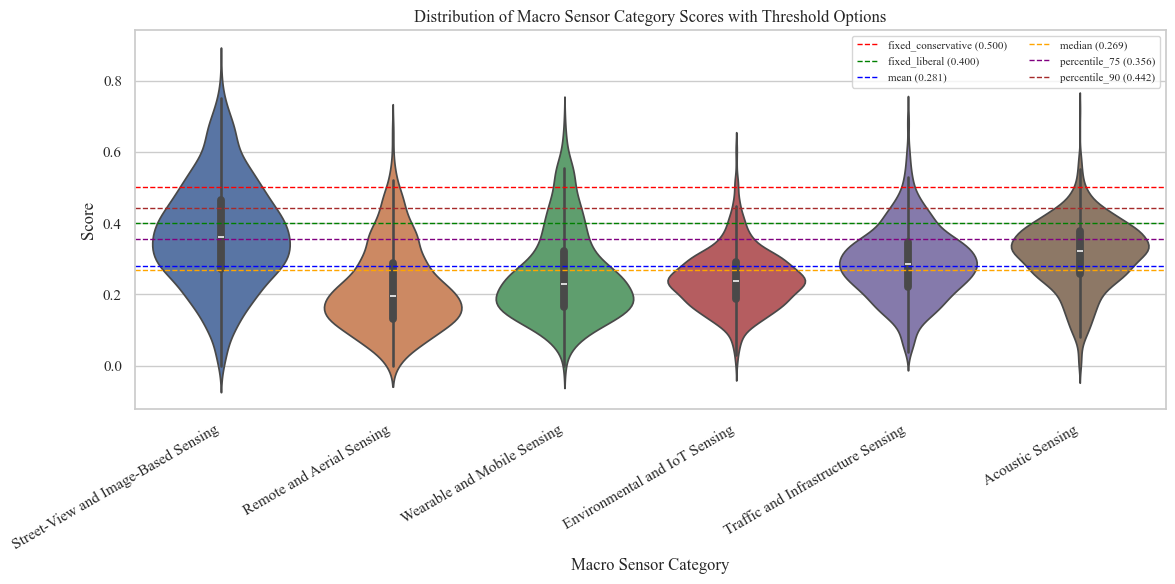

In [9]:
macro_scores_df = pd.DataFrame(list(df_filtered["sensor_macro_scores"]))

all_scores = macro_scores_df.values.flatten()
all_scores = all_scores[~np.isnan(all_scores)]

thresholds = {
    "fixed_conservative": 0.5,
    "fixed_liberal": 0.4,
    "mean": np.mean(all_scores),
    "median": np.median(all_scores),
    "percentile_75": np.percentile(all_scores, 75),
    "percentile_90": np.percentile(all_scores, 90),
}

print("Possible thresholds:")
for name, value in thresholds.items():
    print(f"  - {name}: {value:.4f}")

print("\nMacro categories assigned per abstract with different thresholds:")
for name, threshold in thresholds.items():
    categories_per_abstract = (macro_scores_df >= threshold).sum(axis=1)
    print(f"  - {name} (threshold={threshold:.4f}): {categories_per_abstract.mean():.2f} categories per abstract")

plt.figure(figsize=(12, 6))
sns.violinplot(data=macro_scores_df)
plt.xticks(rotation=30, ha="right")
plt.title("Distribution of Macro Sensor Category Scores with Threshold Options")
plt.ylabel("Score")
plt.xlabel("Macro Sensor Category")

colors = ["red", "green", "blue", "orange", "purple", "brown"]
for (name, threshold), color in zip(thresholds.items(), colors):
    plt.axhline(y=threshold, color=color, linestyle="--", linewidth=1, label=f"{name} ({threshold:.3f})")

plt.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# Calibrating the Threshold Against `real.json`

Instead of the "mean" heuristic, this calibrates against the same labeled validation
set used for inclusion/exclusion screening (`real.json`).

Unlike the dimension notebook, this uses **both** classes here, not just `label == 1`.
For walkability dimensions, `label == 0` (excluded at screening) is a contaminated
negative signal -- an excluded article can still discuss a dimension topically without
a sensor measuring it. For sensor detection specifically, that caveat is much weaker:
"does not use a sensor" is literally one of the three original adjudication rules used
to exclude articles at screening, so a meaningful share of `label == 0` records were
excluded precisely because they use no sensor at all. That makes `label == 0` usable
here to inform where the threshold should sit, via the same ROC-based, target-recall
calibration used in the original screening pipeline (`threshold_for_target_recall`),
rather than a recall-only cut computed from the 46 positives alone.

That distinction also explains why the first attempt at this calibration overshot:
at the "mean" threshold (0.2846), recall among confirmed positives was already 100%
-- recall was never the deficient axis here, over-assignment (precision) was. Forcing
a target of 70% recall when recall was not the problem pushed the threshold far
higher than necessary (0.5539), driven by an order statistic over only ~46 positives,
and left 807 of 968 corpus articles with no sensor category at all. The ROC-based
calibration below targets a high recall (95%, matching the target used for the
inclusion/exclusion screening step, since there is no reason to give up recall here)
and lets the full ROC curve -- informed by both classes -- pick the least aggressive
threshold that still clears it.

In [10]:
real_df = pd.read_json("../model/dataset/real.json")

REAL_TEXT_FIELD_CANDIDATES = ["introduction", "contribution", "abstract", "text", "contribution_text"]
REAL_LABEL_FIELD_CANDIDATES = ["label", "is_walkability_related", "walkability", "y", "class"]
POSITIVE_LABEL_VALUES = {1, "1", True, "true", "True", "positive", "Positive", "yes", "Yes", "Sensing of walkability dimension", "sensing of walkability dimension"}

def get_text(record, field_candidates=REAL_TEXT_FIELD_CANDIDATES):
    for field in field_candidates:
        val = record.get(field)
        if isinstance(val, str) and val.strip():
            return val.strip()
    return None

def get_label(record, field_candidates=REAL_LABEL_FIELD_CANDIDATES, positive_values=POSITIVE_LABEL_VALUES):
    for field in field_candidates:
        if field in record and record[field] is not None:
            return 1 if record[field] in positive_values else 0
    return None

real_df["text"] = real_df.apply(lambda r: get_text(r.to_dict()), axis=1)
real_df["label"] = real_df.apply(lambda r: get_label(r.to_dict()), axis=1)
real_df = real_df.dropna(subset=["text", "label"]).reset_index(drop=True)
real_df["label"] = real_df["label"].astype(int)

print(f"Loaded {len(real_df)} labeled records from real.json ",
      f"({real_df['label'].sum()} positive / confirmed sensor-based walkability-dimension articles)")

tqdm.pandas(desc="Detecting sensor technologies in real.json")
real_detection = real_df["text"].progress_apply(detect_sensor_technologies)
real_df["macro_scores"] = real_detection.apply(lambda r: r["macro_scores"])
real_df["best_sensor_score"] = real_df["macro_scores"].apply(lambda s: max(s.values()))

Loaded 100 labeled records from real.json  (46 positive / confirmed sensor-based walkability-dimension articles)


Detecting sensor technologies in real.json: 100%|██████████| 100/100 [00:13<00:00,  7.40it/s]


In [11]:
def threshold_for_target_recall(y_true, scores, target_recall):
    """Lowest score threshold such that recall on y_true >= target_recall, using
    the full ROC curve (both classes) rather than an order statistic over positives
    only -- the same approach used to calibrate the inclusion/exclusion screening
    step earlier in this project."""
    from sklearn.metrics import roc_curve
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    valid = tpr >= target_recall
    if not valid.any():
        best_idx = int(np.argmax(tpr))
        return float(thresholds[best_idx]), float(tpr[best_idx])
    candidate_idxs = np.where(valid)[0]
    best_idx = candidate_idxs[np.argmax(thresholds[candidate_idxs])]
    return float(thresholds[best_idx]), float(tpr[best_idx])


# 0.95 to match the recall target used for inclusion/exclusion screening -- there is
# no reason to deliberately give up recall here, unlike the earlier 0.70 attempt.
TARGET_SENSOR_RECALL = 0.95

CALIBRATED_THRESHOLD, achieved_recall = threshold_for_target_recall(
    real_df["label"], real_df["best_sensor_score"], TARGET_SENSOR_RECALL
)

recall_at_mean = float((real_df.loc[real_df["label"] == 1, "best_sensor_score"] >= 0.2846).mean())

print(f"Calibrated threshold: {CALIBRATED_THRESHOLD:.4f}")
print(f"Achieved recall among confirmed positives at this threshold: {achieved_recall:.3f}")
print(f"(compare: mean-heuristic=0.2846 achieved recall {recall_at_mean:.3f} among the same confirmed positives)")

Calibrated threshold: 0.4284
Achieved recall among confirmed positives at this threshold: 0.957
(compare: mean-heuristic=0.2846 achieved recall 1.000 among the same confirmed positives)


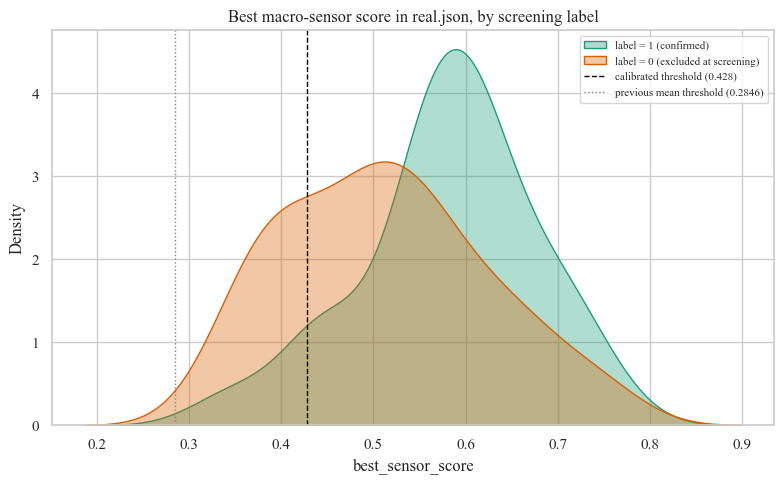

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
for label_value, label_name, color in [(1, "label = 1 (confirmed)", "#1b9e77"),
                                        (0, "label = 0 (excluded at screening)", "#d95f02")]:
    subset = real_df.loc[real_df["label"] == label_value, "best_sensor_score"]
    sns.kdeplot(subset, ax=ax, fill=True, alpha=0.35, color=color, label=label_name, clip=(0, 1))
ax.axvline(CALIBRATED_THRESHOLD, color="black", linestyle="--", linewidth=1,
           label=f"calibrated threshold ({CALIBRATED_THRESHOLD:.3f})")
ax.axvline(0.2846, color="gray", linestyle=":", linewidth=1, label="previous mean threshold (0.2846)")
ax.set_title("Best macro-sensor score in real.json, by screening label")
ax.set_xlabel("best_sensor_score")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Assign Macro Sensor Categories

Uses the mean-based threshold by default rather than a fixed round number, given the
dilution problem observed with a fixed 0.5 threshold on the dimension-classification
notebook. Review the plot above and adjust `CONFIG_SCORE_THRESHOLD` before treating
the assignment as final; validating it against a small manually coded sample (the same
principle already applied to the inclusion/exclusion screening step) is recommended
before reporting these counts.

In [13]:
# Uses the threshold calibrated against real.json above, instead of the "mean"
# heuristic. Adjust TARGET_SENSOR_RECALL in the calibration section above (not this
# value directly) if a different trade-off is preferred, then re-run from that cell.
CONFIG_SCORE_THRESHOLD = CALIBRATED_THRESHOLD

def assign_macro_sensor_categories(macro_scores, threshold):
    return [category for category, score in macro_scores.items() if score >= threshold]

df_filtered["macro_sensor_types"] = df_filtered["sensor_macro_scores"].apply(
    lambda scores: assign_macro_sensor_categories(scores, CONFIG_SCORE_THRESHOLD)
)

category_counts = Counter()
for categories in df_filtered["macro_sensor_types"]:
    category_counts.update(categories)

print(f"Threshold used: {CONFIG_SCORE_THRESHOLD:.4f}\n")
print("Sensor category distribution:")
for category, count in category_counts.most_common():
    print(f"  - {category}: {count} abstracts")

avg_categories = np.mean([len(c) for c in df_filtered["macro_sensor_types"]])
multi_category = sum(1 for c in df_filtered["macro_sensor_types"] if len(c) > 1)
print(f"\nAverage sensor categories per abstract: {avg_categories:.2f}")
print(f"Abstracts with multiple sensor categories: {multi_category} ({multi_category/len(df_filtered)*100:.2f}%)")

Threshold used: 0.4284

Sensor category distribution:
  - Street-View and Image-Based Sensing: 314 abstracts
  - Wearable and Mobile Sensing: 109 abstracts
  - Acoustic Sensing: 85 abstracts
  - Traffic and Infrastructure Sensing: 78 abstracts
  - Remote and Aerial Sensing: 57 abstracts
  - Environmental and IoT Sensing: 24 abstracts

Average sensor categories per abstract: 0.69
Abstracts with multiple sensor categories: 173 (17.87%)


# Visualize Sensor Category Distribution

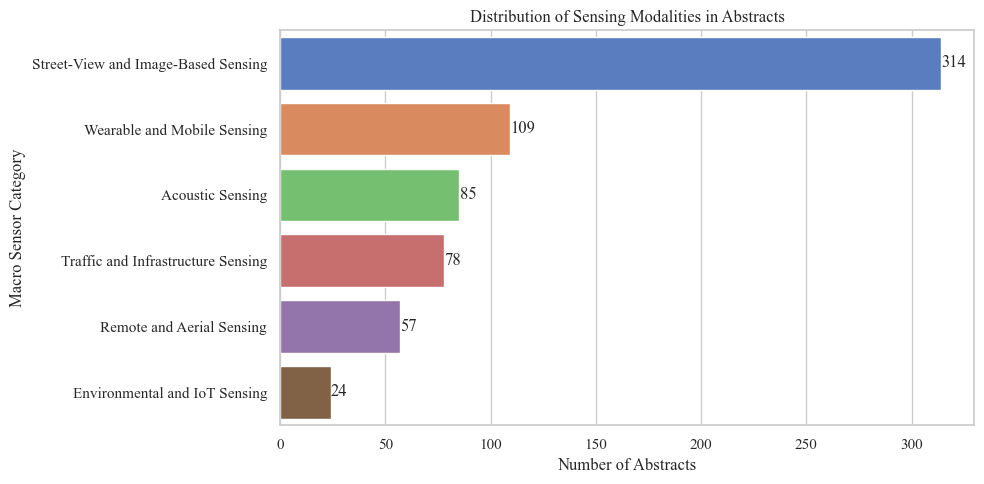

In [14]:
palette = sns.color_palette("muted", n_colors=len(category_counts))
categories_list = [category for category, count in category_counts.most_common()]
counts = [count for category, count in category_counts.most_common()]

plt.figure(figsize=(10, 5))
sns.barplot(x=counts, y=categories_list, hue=categories_list, palette=palette, legend=False)
plt.xlabel("Number of Abstracts")
plt.ylabel("Macro Sensor Category")
plt.title("Distribution of Sensing Modalities in Abstracts")

for i, count in enumerate(counts):
    plt.text(count + 0.2, i, str(count), va="center")

plt.tight_layout()
plt.show()

# Filter Articles with No Sensor Category Assigned

In [15]:
no_category_mask = df_filtered["macro_sensor_types"].apply(lambda x: len(x) == 0)
no_category_df = df_filtered[no_category_mask]

df_filtered = df_filtered[~no_category_mask].copy()
df_filtered = df_filtered.reset_index(drop=True)
print(f"Filtered DataFrame size: {len(df_filtered)} articles with an assigned sensor category")
print(f"Articles with no sensor category assigned: {len(no_category_df)}")

Filtered DataFrame size: 448 articles with an assigned sensor category
Articles with no sensor category assigned: 520


# Save the Results

Saves `macro_sensor_types` keyed by DOI, so it can be merged into the walkability
dimension output (`06_2_classified_walkability_dimensions.json`) for the sensor x
dimension crosstab already stubbed into that notebook.

In [16]:
df_filtered.to_json("../data/06_3_classified_sensor_types.json", orient="records", indent=4)
no_category_df.to_json("../data/06_3_1_no_assigned_sensor_types.json", orient="records", indent=4)

print(f"Saved:\n  ../data/06_3_classified_sensor_types.json ({len(df_filtered)} records)"
      f"\n  ../data/06_3_1_no_assigned_sensor_types.json ({len(no_category_df)} records)")

Saved:
  ../data/06_3_classified_sensor_types.json (448 records)
  ../data/06_3_1_no_assigned_sensor_types.json (520 records)


# Merge into the Dimension-Classified File (Optional)

Run this after both `06_2_Walkability_Dimension_Classification.ipynb` and this
notebook have produced their outputs, to populate the sensor x dimension crosstab
cell already present in the dimension notebook.

In [17]:
dimension_path = "../data/06_2_classified_walkability_dimensions.json"
if os.path.exists(dimension_path):
    df_dimensions = pd.read_json(dimension_path)
    merged = df_dimensions.merge(
        df_filtered[["doi", "macro_sensor_types"]], on="doi", how="left"
    )
    merged.to_json("../data/06_4_dimensions_with_sensor_types.json", orient="records", indent=4)
    print(f"Saved ../data/06_4_dimensions_with_sensor_types.json ({len(merged)} records) "
          f"-- re-run the crosstab cell in the dimension notebook against this file.")
else:
    print(f"{dimension_path} not found yet -- run the dimension-classification notebook first.")

Saved ../data/06_4_dimensions_with_sensor_types.json (737 records) -- re-run the crosstab cell in the dimension notebook against this file.
